2025-04-23 22:03:33.123523
2024-04-23 22:03:33.123523


[*********************100%***********************]  1 of 1 completed

                  NVDA
Date                  
2024-04-24   79.650833
2024-04-25   82.604866
2024-04-26   87.706177
2024-04-29   87.728172
2024-04-30   86.373611
...                ...
2025-04-15  112.199997
2025-04-16  104.489998
2025-04-17  101.489998
2025-04-21   96.910004
2025-04-22   98.889999

[249 rows x 1 columns]


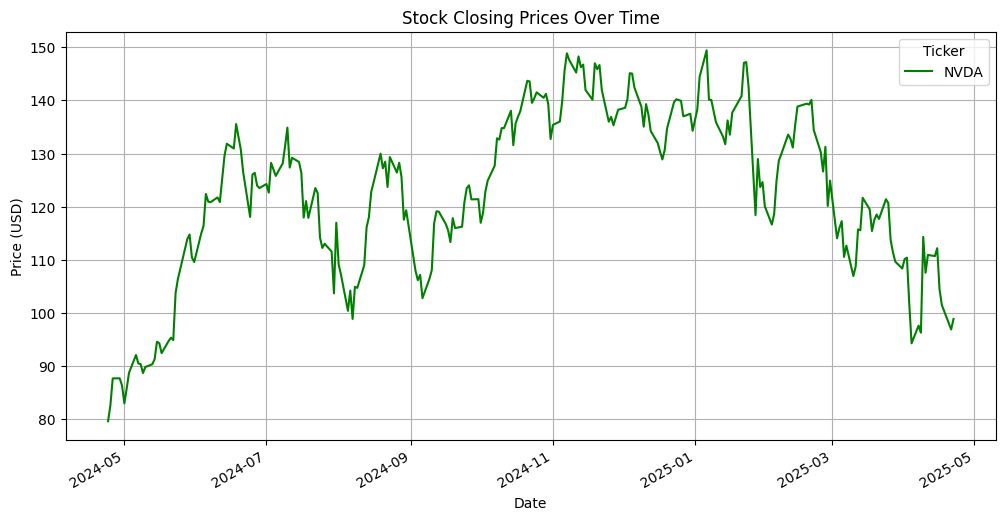

In [ ]:
import yfinance as yf
import pandas as pd 
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

tickers = []
while True:
    user_input = str(input("Enter the names of the stock you'd like to view.\nEnter 'STOP' when done: "))
    if user_input == 'STOP':
        break
    tickers.append(user_input)

end_date = datetime.now() + timedelta(days = 1)
print(end_date)
day = int(input("Enter the amount of days ago for which you'd like to view stock history: "))
start_date = end_date - timedelta(days = day)
print(start_date)

close_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date)
    close_df[ticker] = data['Close']

class FindPriceAtTime:
    def __init__(self, ticker):
        self.ticker = ticker.upper()

    def get_price_at(self, date_str):
        if len(date_str) != 10 or date_str[4] != '-' or date_str[7] != '-':
            print("Date format must be YYYY-MM-DD.")
            return None
        year, month, day = map(int, date_str.split('-'))
        date = datetime(year, month, day)
        next_day = date + timedelta(days=1)
        data = yf.download(self.ticker, start=date_str, end=next_day.strftime("%Y-%m-%d"), progress=False)
        if data.empty or 'Close' not in data.columns:
            print(f"No data found for {self.ticker} on {date_str}.")
            return None
        close_price = data.loc[data.index[0], 'Close']  
        return round(close_price, 2)  



print(close_df)
close_df.plot(figsize=(12, 6), title="Stock Closing Prices Over Time", color = 'g')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend(title="Ticker")
plt.show()

do_lookup = input("Do you want to find the closing price of a stock on a certain date? [Y/N]: ").strip().upper()
if do_lookup == 'Y':
    stock = input("Enter the stock ticker you'd like to check: ").strip().upper()
    date = input("Enter the date you'd like to check [YYYY-MM-DD]: ").strip()
    price_finder = FindPriceAtTime(stock)
    price = price_finder.get_price_at(date)
    if price is not None:
        print(f"Closing price for {stock} on {date} was: ${price}")
    else:
        print("Price data not available.")
    


